## Introduction

This notebook focuses on preprocessing grey seal vocalisation data in preparation for supervised machine learning. 
Raw audio recordings and their corresponding annotation files are used to extract time–frequency regions of interest corresponding to individual seal calls. 
Each call is converted into a fixed-size spectrogram representation suitable for input into a convolutional neural network (CNN).

The output of this notebook is a clean, reproducible dataset containing labelled spectrogram slices, which is saved locally and used for model training in subsequent notebooks

## Data location

In [7]:
from pathlib import Path


# Project root is one level above /notebooks
PROJECT_ROOT = Path.cwd().parent

PROJECT_ROOT


DATA_DIR = Path("C:/Users/hugoc/Downloads/GreySealData/GreySealData")

assert DATA_DIR.exists(), "GreySealData directory not found"

# List top-level contents of GreySealData
list(DATA_DIR.iterdir())



[WindowsPath('C:/Users/hugoc/Downloads/GreySealData/GreySealData/additional-grey-seal-data'),
 WindowsPath('C:/Users/hugoc/Downloads/GreySealData/GreySealData/Guttural rupe'),
 WindowsPath('C:/Users/hugoc/Downloads/GreySealData/GreySealData/Moan'),
 WindowsPath('C:/Users/hugoc/Downloads/GreySealData/GreySealData/Rupes A and B')]

## Loading annotations

In [18]:
import pandas as pd

# Directory for Rupes A and B calls
RUPES_DIR = DATA_DIR / "Rupes A and B"

# Inspect directory contents
list(RUPES_DIR.iterdir())


[WindowsPath('C:/Users/hugoc/Downloads/GreySealData/GreySealData/Rupes A and B/5713.210806110002.Table.1.selections.txt'),
 WindowsPath('C:/Users/hugoc/Downloads/GreySealData/GreySealData/Rupes A and B/5713.210806110002.wav'),
 WindowsPath('C:/Users/hugoc/Downloads/GreySealData/GreySealData/Rupes A and B/5713.210807110002.Table.1.selections.txt'),
 WindowsPath('C:/Users/hugoc/Downloads/GreySealData/GreySealData/Rupes A and B/5713.210807110002.wav'),
 WindowsPath('C:/Users/hugoc/Downloads/GreySealData/GreySealData/Rupes A and B/5713.210808110002.Table.1.selections.txt'),
 WindowsPath('C:/Users/hugoc/Downloads/GreySealData/GreySealData/Rupes A and B/5713.210808110002.wav'),
 WindowsPath('C:/Users/hugoc/Downloads/GreySealData/GreySealData/Rupes A and B/5713.210809120002.Table.1.selections.txt'),
 WindowsPath('C:/Users/hugoc/Downloads/GreySealData/GreySealData/Rupes A and B/5713.210809120002.wav'),
 WindowsPath('C:/Users/hugoc/Downloads/GreySealData/GreySealData/Rupes A and B/5713.21081114

In [19]:
# Load one annotation file
ann_path = sorted(RUPES_DIR.glob("*.Table.1.selections.txt"))[0]
print("Annotation file:", ann_path.name)

df = pd.read_csv(ann_path, sep="\t")

df.head()


Annotation file: 5713.210806110002.Table.1.selections.txt


,Selection,View,Channel,Begin Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),Delta Time (s),Delta Freq (Hz),Avg Power Density (dB FS/Hz),Annotation
0,1,Spectrogram 1,1,13.433865,13.703649,53.191,324.361,0.2698,271.170,-79.66,Rupe B
1,2,Spectrogram 1,1,26.072555,26.283886,53.191,376.259,0.2113,323.068,-84.94,Rupe B
2,3,Spectrogram 1,1,53.382769,53.528888,66.489,478.723,0.1461,412.234,-89.26,Rupe A
3,4,Spectrogram 1,1,65.997665,66.110075,59.347,415.430,0.1124,356.083,-86.86,Rupe A
4,5,Spectrogram 1,1,81.003161,81.266117,59.347,376.259,0.2630,316.912,-82.32,Rupe B


In [20]:
df["Annotation"].value_counts()


Annotation
Rupe A      73
Rupe B      53
Type 4 A    10
Rupe C       4
Name: count, dtype: int64

In [16]:
wav_path = ann_path.name.replace(".Table.1.selections.txt", ".wav")
wav_path = RUPES_DIR / wav_path

wav_path, wav_path.exists()


(WindowsPath('C:/Users/hugoc/Downloads/GreySealData/GreySealData/Rupes A and B/5713.210806110002.wav'),
 True)

In [21]:
# Select the first annotation row
row = df.iloc[0]

row


Selection                                   1
View                            Spectrogram 1
Channel                                     1
Begin Time (s)                      13.433865
End Time (s)                        13.703649
Low Freq (Hz)                          53.191
High Freq (Hz)                        324.361
Delta Time (s)                         0.2698
Delta Freq (Hz)                        271.17
Avg Power Density (dB FS/Hz)           -79.66
Annotation                             Rupe B
Name: 0, dtype: object

## Spectrogram generation

Sample rate: 96000 Hz | Duration: 1199.98 s | Label: Rupe B
Segment seconds: 12.434 to 14.704 | samples: 217899 | dtype: int16
Spectrogram shape: (513, 848)
Slice shape: (3, 102)


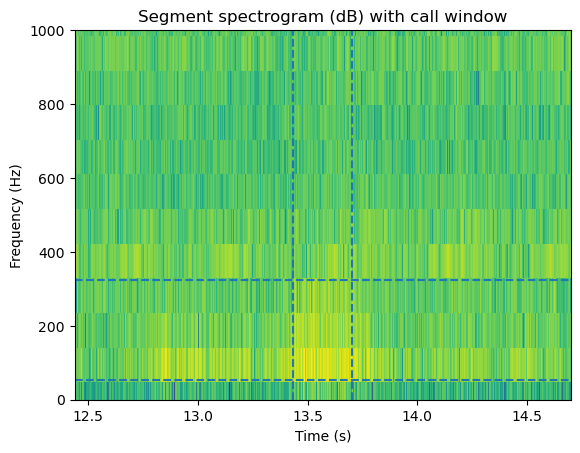

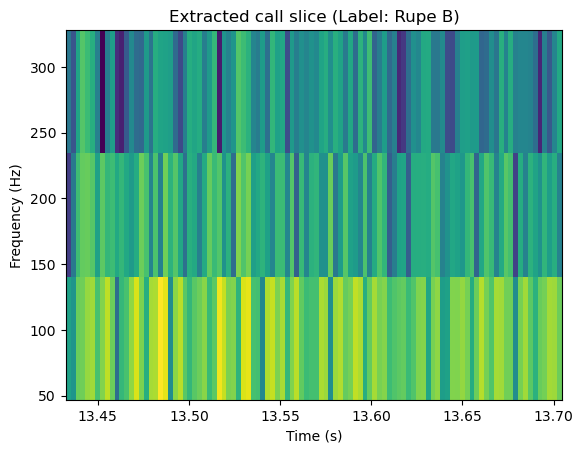

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import spectrogram

# --- Values from the row ---
t0 = float(row["Begin Time (s)"])
t1 = float(row["End Time (s)"])
f0 = float(row["Low Freq (Hz)"])
f1 = float(row["High Freq (Hz)"])
label = row["Annotation"]

wav_path = RUPES_DIR / ann_path.name.replace(".Table.1.selections.txt", ".wav")

# --- Load wav (keep original dtype; do NOT convert whole thing) ---
sr, audio_raw = wavfile.read(wav_path)

# If stereo/multi-channel, downmix WITHOUT converting whole file to float
if audio_raw.ndim > 1:
    # average channels in float64 would be big; do it in int -> then cast segment later
    audio_raw = audio_raw.mean(axis=1).astype(audio_raw.dtype)

duration = len(audio_raw) / sr
print("Sample rate:", sr, "Hz | Duration:", round(duration, 2), "s | Label:", label)

# --- Slice indices first ---
pad = 1.0
start_t = max(0.0, t0 - pad)
end_t = min(duration, t1 + pad)
start_i = int(start_t * sr)
end_i = int(end_t * sr)

seg = audio_raw[start_i:end_i]  # small view/copy only of the segment
print("Segment seconds:", round(start_t, 3), "to", round(end_t, 3),
      "| samples:", len(seg), "| dtype:", seg.dtype)

# --- Convert ONLY the segment to float32 and normalise ---
if np.issubdtype(seg.dtype, np.integer):
    seg = seg.astype(np.float32) / np.iinfo(seg.dtype).max
else:
    seg = seg.astype(np.float32)

# --- Spectrogram on the segment only ---
nperseg = 1024
noverlap = 768

freqs, times, Sxx = spectrogram(
    seg, fs=sr,
    nperseg=nperseg, noverlap=noverlap,
    scaling="density", mode="magnitude"
)

Sxx_db = 10 * np.log10(Sxx + 1e-10)

# Convert segment-relative times to absolute
times_abs = times + start_t

# --- Extract slice ---
t_mask = (times_abs >= t0) & (times_abs <= t1)
f_mask = (freqs >= f0) & (freqs <= f1)

slice_db = Sxx_db[np.ix_(f_mask, t_mask)]
slice_freqs = freqs[f_mask]
slice_times = times_abs[t_mask]

print("Spectrogram shape:", Sxx_db.shape)
print("Slice shape:", slice_db.shape)

# --- Plot segment spectrogram + highlight window ---
plt.figure()
plt.pcolormesh(times_abs, freqs, Sxx_db, shading="auto")
plt.ylim(0, 1000)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Segment spectrogram (dB) with call window")
plt.axvline(t0, linestyle="--")
plt.axvline(t1, linestyle="--")
plt.axhline(f0, linestyle="--")
plt.axhline(f1, linestyle="--")
plt.show()

# --- Plot extracted slice ---
plt.figure()
plt.pcolormesh(slice_times, slice_freqs, slice_db, shading="auto")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"Extracted call slice (Label: {label})")
plt.show()


### Reusable spectogram slice extraction

In [23]:
def extract_call_slice(
    wav_path,
    row,
    pad=1.0,
    nperseg=1024,
    noverlap=768
):
    """
    Extract a spectrogram slice for a single annotated call.

    Parameters
    ----------
    wav_path : Path
        Path to wav file
    row : pandas.Series
        Annotation row with time/frequency bounds
    pad : float
        Seconds of context before/after the call
    nperseg, noverlap : int
        Spectrogram parameters

    Returns
    -------
    slice_db : np.ndarray
        2D spectrogram slice (freq_bins x time_bins)
    label : str
        Annotation label
    """

    import numpy as np
    from scipy.io import wavfile
    from scipy.signal import spectrogram

    # --- Pull annotation values ---
    t0 = float(row["Begin Time (s)"])
    t1 = float(row["End Time (s)"])
    f0 = float(row["Low Freq (Hz)"])
    f1 = float(row["High Freq (Hz)"])
    label = row["Annotation"]

    # --- Load wav (keep original dtype; do NOT convert whole thing) ---
    sr, audio_raw = wavfile.read(wav_path)

    # If stereo/multi-channel, downmix WITHOUT converting whole file to float
    if audio_raw.ndim > 1:
        audio_raw = audio_raw.mean(axis=1).astype(audio_raw.dtype)

    duration = len(audio_raw) / sr

    # --- Window audio ---
    start_t = max(0.0, t0 - pad)
    end_t = min(duration, t1 + pad)
    start_i = int(start_t * sr)
    end_i = int(end_t * sr)

    seg = audio_raw[start_i:end_i]

    # --- Normalise segment only ---
    if np.issubdtype(seg.dtype, np.integer):
        seg = seg.astype(np.float32) / np.iinfo(seg.dtype).max
    else:
        seg = seg.astype(np.float32)

    # --- Spectrogram ---
    freqs, times, Sxx = spectrogram(
        seg,
        fs=sr,
        nperseg=nperseg, 
        noverlap=noverlap,
        scaling="density", 
        mode="magnitude"
    )

    Sxx_db = 10 * np.log10(Sxx + 1e-10) # to dB
    times_abs = times + start_t

    # --- Extract slice ---
    t_mask = (times_abs >= t0) & (times_abs <= t1)
    f_mask = (freqs >= f0) & (freqs <= f1)

    slice_db = Sxx_db[np.ix_(f_mask, t_mask)]

    return slice_db, label

In [24]:
slice_db, label = extract_call_slice(wav_path, df.iloc[0])
slice_db.shape, label


((3, 102), 'Rupe B')

In [25]:
shapes = []

for i in range(10):
    s, lbl = extract_call_slice(wav_path, df.iloc[i])
    shapes.append(s.shape)

freq_bins = [s[0] for s in shapes]
time_bins = [s[1] for s in shapes]

min(freq_bins), max(freq_bins), min(time_bins), max(time_bins)


(3, 6, 25, 115)

### Standardising spectrogram slice size

In [26]:
import numpy as np

def pad_or_crop_2d(arr, target_shape):
    """
    Pad or crop a 2D array to a fixed target shape.

    Parameters
    ----------
    arr : np.ndarray
        2D array (freq_bins x time_bins)
    target_shape : tuple
        (target_freq_bins, target_time_bins)

    Returns
    -------
    out : np.ndarray
        2D array of shape target_shape
    """

    target_f, target_t = target_shape
    f, t = arr.shape

    # --- Crop if too large ---
    arr = arr[:target_f, :target_t]

    # --- Pad if too small ---
    pad_f = max(0, target_f - arr.shape[0])
    pad_t = max(0, target_t - arr.shape[1])

    out = np.pad(
        arr,
        pad_width=((0, pad_f), (0, pad_t)),
        mode="constant",
        constant_values=0
    )

    return out


In [27]:
# ---Test padding/cropping on one slice---

TARGET_SHAPE = (6, 115)

slice_db, label = extract_call_slice(wav_path, df.iloc[0])
fixed_slice = pad_or_crop_2d(slice_db, TARGET_SHAPE)

slice_db.shape, fixed_slice.shape, label



((3, 102), (6, 115), 'Rupe B')

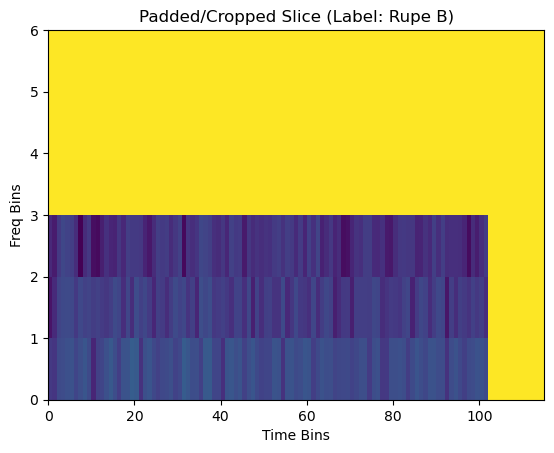

In [28]:
# --- Visual sanity check ---

import matplotlib.pyplot as plt

plt.figure()
plt.pcolormesh(fixed_slice, shading="auto")
plt.title(f"Padded/Cropped Slice (Label: {label})")
plt.xlabel("Time Bins")
plt.ylabel("Freq Bins")
plt.show()

### Building dataset from a single annotation file

In [29]:
x = []
y = []

for idx, row in df.iterrows():
    try:
        slice_db, label = extract_call_slice(wav_path, row)
        fixed_slice = pad_or_crop_2d(slice_db, TARGET_SHAPE)

        x.append(fixed_slice)
        y.append(label)

    except Exception as e:
        print(f"skippimg row {idx} due to error:" , e)

len(x), len(y)


(140, 140)

In [30]:
# --- Convert to arrays ---

import numpy as np

x = np.array(x)
y = np.array(y)

x.shape, y.shape


((140, 6, 115), (140,))

In [31]:
# -- Quick checks ---

np.unique(y, return_counts=True)


(array(['Rupe A', 'Rupe B', 'Rupe C', 'Type 4 A'], dtype='<U8'),
 array([73, 53,  4, 10], dtype=int64))

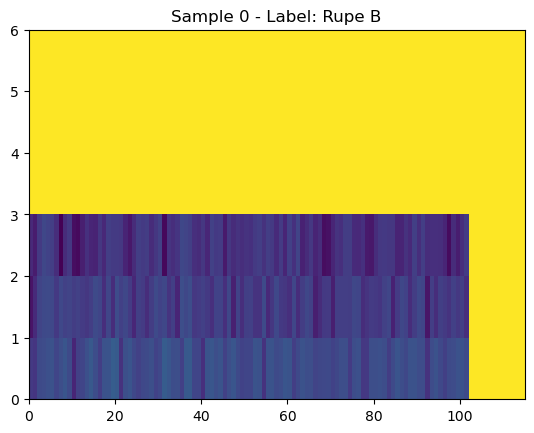

In [32]:
# Sample visually ---

import matplotlib.pyplot as plt
plt.figure()
plt.pcolormesh(x[0], shading="auto")
plt.title(f"Sample 0 - Label: {y[0]}")
plt.show()


### Fiter to Rupe A and  Rupe B

In [33]:
import numpy as np

X_list = []
y_list = []

for idx, row in df.iterrows():
    try:
        slice_db, label = extract_call_slice(wav_path, row)
        fixed_slice = pad_or_crop_2d(slice_db, TARGET_SHAPE)

        X_list.append(fixed_slice)
        y_list.append(label)

    except Exception as e:
        print(f"Skipping row {idx} due to error:", e)

X = np.stack(X_list)
y = np.array(y_list)

X.shape, y.shape, np.unique(y, return_counts=True)


((140, 6, 115),
 (140,),
 (array(['Rupe A', 'Rupe B', 'Rupe C', 'Type 4 A'], dtype='<U8'),
  array([73, 53,  4, 10], dtype=int64)))

### Encode labels to integers

In [34]:
mask = np.isin(y, ["Rupe A", "Rupe B"])
X_ab = X[mask]
y_ab = y[mask]

X_ab.shape, np.unique(y_ab, return_counts=True)


((126, 6, 115),
 (array(['Rupe A', 'Rupe B'], dtype='<U8'), array([73, 53], dtype=int64)))

### Save dataset locally (ignored by git)

In [35]:
label_map = {"Rupe A": 0, "Rupe B": 1}
y_ab_int = np.vectorize(label_map.get)(y_ab).astype(np.int64)

np.unique(y_ab_int, return_counts=True), y_ab[:5], y_ab_int[:5]


((array([0, 1], dtype=int64), array([73, 53], dtype=int64)),
 array(['Rupe B', 'Rupe B', 'Rupe A', 'Rupe A', 'Rupe B'], dtype='<U8'),
 array([1, 1, 0, 0, 1], dtype=int64))

In [36]:
import numpy as np
from pathlib import Path

out_dir = PROJECT_ROOT / "data_processed"
out_dir.mkdir(exist_ok=True)

out_path = out_dir / "dataset_rupeA_rupeB_v1.npz"

np.savez_compressed(
    out_path,
    X=X_ab.astype(np.float32),
    y=y_ab_int,
    label_map=np.array([("Rupe A", 0), ("Rupe B", 1)], dtype=object),
    target_shape=np.array(TARGET_SHAPE, dtype=np.int64)
)

out_path, out_path.exists(), out_path.stat().st_size


(WindowsPath('c:/repos/finalproject-hugcamrom/data_processed/dataset_rupeA_rupeB_v1.npz'),
 True,
 108623)

## Next steps

The processed dataset generated in this notebook is used as input to a baseline convolutional neural network.
The next notebook focuses on model training, validation, and evaluation, including performance metrics and visualisation of classification results.

## References

- Cornell Lab of Ornithology. **Raven Pro: Interactive Sound Analysis Software** (documentation and resources).  
  https://ravensoundsoftware.com/software/raven-pro/

- SciPy Developers. **`scipy.signal.spectrogram` documentation** (spectrogram computation used in preprocessing).  
  https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.spectrogram.html

- NumPy Developers. **`numpy.savez_compressed` documentation** (used to export the processed dataset locally).  
  https://numpy.org/doc/stable/reference/generated/numpy.savez_compressed.html


## Notes

- **Raw dataset is not included** in this repository (audio and annotations are provided separately for the module).  
- The processed dataset is exported locally to `data_processed/` and excluded from version control via `.gitignore`.  
- This notebook produces **fixed-size spectrogram arrays** to ensure consistent input shape for downstream ML models.
